In [3]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings(action="ignore")
from tensorflow.keras.applications import VGG19, ResNet50
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.models import Model, Sequential
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import time
from sklearn.metrics import roc_curve, auc
import itertools
from sklearn.metrics import confusion_matrix, roc_curve, auc
# Paths to your dataset
healthy_dirs = [
    r'DS/input/Osteoporosis Knee X-ray/normal',
    r'DS/input/osteoporosis-knee-xray-dataset/normal/normal',
    r'DS/input/Osteoporosis Knee Dataset/Normal',
    r'DS/input/Osteoporosis/normal'
]

osteoporosis_dirs = [
    r'DS/input/Osteoporosis Knee X-ray/osteoporosis',
    r'DS/input/osteoporosis-knee-xray-dataset/osteoporosis/osteoporosis',
    r'DS/input/Osteoporosis Knee Dataset/Osteoporosis',
    r'DS/input/Osteoporosis/osteoporosis'
]

# Dataset preparation
filepaths, labels = [], []
dict_lists = [healthy_dirs, osteoporosis_dirs]
class_labels = ['Healthy', 'Osteoporosis']

for i, dir_list in enumerate(dict_lists):
    for dir in dir_list:
        flist = os.listdir(dir)
        for f in flist:
            fpath = os.path.join(dir, f)
            filepaths.append(fpath)
            labels.append(class_labels[i])

Fseries = pd.Series(filepaths, name="filepaths")
Lseries = pd.Series(labels, name="labels")
df = pd.concat([Fseries, Lseries], axis=1)

# Splitting dataset
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.3, random_state=42)
val_set, _ = train_test_split(test_set, test_size=0.5, random_state=42)  # Further split for validation

# Enhanced Data Augmentation for training set
image_gen_train = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input,
                                     rotation_range=20,
                                     width_shift_range=0.2,
                                     height_shift_range=0.2,
                                     shear_range=0.2,
                                     zoom_range=0.2,
                                     horizontal_flip=True,
                                     fill_mode='nearest')

# Standard preprocessing for test and validation sets
image_gen_test_val = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg19.preprocess_input)

# Flow from dataframe for train, test, and validation
train = image_gen_train.flow_from_dataframe(dataframe=train_set, x_col="filepaths", y_col="labels",
                                            target_size=(224, 224), color_mode='rgb',
                                            class_mode="categorical", batch_size=4, shuffle=True)
test = image_gen_test_val.flow_from_dataframe(dataframe=test_set, x_col="filepaths", y_col="labels",
                                              target_size=(224, 224), color_mode='rgb',
                                              class_mode="categorical", batch_size=4, shuffle=False)
val = image_gen_test_val.flow_from_dataframe(dataframe=val_set, x_col="filepaths", y_col="labels",
                                             target_size=(224, 224), color_mode='rgb',
                                             class_mode="categorical", batch_size=4, shuffle=False)

# Model Creation with L2 Regularization and Batch Normalization
def create_model(model_type):
    if model_type == 'VGG19':
        base_model = VGG19(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
        x = base_model.output
    elif model_type == 'ResNet50':
        base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))
        x = base_model.output
    elif model_type == 'Sequential_CNN':
        model = Sequential([
            Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=(224, 224, 3)),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
            MaxPooling2D((2, 2)),
            BatchNormalization(),
            Flatten(),
            Dense(512, activation='relu'),
            Dropout(0.5),
            Dense(2, activation='softmax')
        ])
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model
    else:
        raise ValueError("Unsupported model type")
    
    x = Flatten()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(2, activation='softmax')(x)
    
    model = Model(inputs=base_model.input, outputs=predictions)
    
    for layer in base_model.layers:
        layer.trainable = False
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model



Found 1101 validated image filenames belonging to 2 classes.
Found 472 validated image filenames belonging to 2 classes.
Found 236 validated image filenames belonging to 2 classes.


In [4]:
# Create and train models
vgg19_model = create_model('VGG19')
resnet50_model = create_model('ResNet50')
sequential_cnn_model = create_model('Sequential_CNN')



94765736/94765736 [==============================] - 2s 0us/step


In [5]:
# Training VGG19
print("Training VGG19")
vgg19_history = vgg19_model.fit(train, epochs=10, validation_data=val, verbose=1)



Training VGG19
Epoch 1/10
276/276 [==============================] - 298s 1s/step - loss: 31.7893 - accuracy: 0.7094 - val_loss: 6.9585 - val_accuracy: 0.7797
Epoch 2/10
276/276 [==============================] - 275s 996ms/step - loss: 5.7611 - accuracy: 0.8574 - val_loss: 3.0309 - val_accuracy: 0.8051
Epoch 3/10
276/276 [==============================] - 250s 906ms/step - loss: 2.9921 - accuracy: 0.8719 - val_loss: 1.6734 - val_accuracy: 0.8771
Epoch 4/10
276/276 [==============================] - 259s 937ms/step - loss: 1.7110 - accuracy: 0.9001 - val_loss: 1.4784 - val_accuracy: 0.8644
Epoch 5/10
276/276 [==============================] - 256s 927ms/step - loss: 1.6951 - accuracy: 0.9146 - val_loss: 1.0978 - val_accuracy: 0.8941
Epoch 6/10
276/276 [==============================] - 251s 910ms/step - loss: 0.9847 - accuracy: 0.9192 - val_loss: 1.3144 - val_accuracy: 0.9025
Epoch 7/10
276/276 [==============================] - 251s 908ms/step - loss: 0.6928 - accuracy: 0.9201 - val_l

In [7]:
# Training ResNet50
print("\nTraining ResNet50")
resnet50_history = resnet50_model.fit(train, epochs=10, validation_data=val, verbose=1)




Training ResNet50
Epoch 1/10
276/276 [==============================] - 248s 816ms/step - loss: 50.3307 - accuracy: 0.7275 - val_loss: 10.0810 - val_accuracy: 0.8475
Epoch 2/10
276/276 [==============================] - 204s 739ms/step - loss: 12.1237 - accuracy: 0.8238 - val_loss: 5.2885 - val_accuracy: 0.8432
Epoch 3/10
276/276 [==============================] - 209s 757ms/step - loss: 3.9347 - accuracy: 0.8692 - val_loss: 2.9642 - val_accuracy: 0.8814
Epoch 4/10
276/276 [==============================] - 202s 729ms/step - loss: 1.3579 - accuracy: 0.9237 - val_loss: 1.6705 - val_accuracy: 0.8814
Epoch 5/10
276/276 [==============================] - 200s 724ms/step - loss: 0.7780 - accuracy: 0.9346 - val_loss: 1.1638 - val_accuracy: 0.9068
Epoch 6/10
276/276 [==============================] - 199s 720ms/step - loss: 0.7096 - accuracy: 0.9264 - val_loss: 1.2781 - val_accuracy: 0.8771
Epoch 7/10
276/276 [==============================] - 205s 742ms/step - loss: 0.8335 - accuracy: 0.908

In [8]:
# Training Sequential CNN
print("\nTraining Sequential CNN")
sequential_cnn_history = sequential_cnn_model.fit(train, epochs=10, validation_data=val, verbose=1)




Training Sequential CNN
Epoch 1/10
276/276 [==============================] - 139s 464ms/step - loss: 14.3703 - accuracy: 0.7293 - val_loss: 0.4919 - val_accuracy: 0.7966
Epoch 2/10
276/276 [==============================] - 124s 450ms/step - loss: 0.4338 - accuracy: 0.8220 - val_loss: 0.4087 - val_accuracy: 0.7966
Epoch 3/10
276/276 [==============================] - 124s 450ms/step - loss: 0.4219 - accuracy: 0.8392 - val_loss: 0.3708 - val_accuracy: 0.8263
Epoch 4/10
276/276 [==============================] - 128s 464ms/step - loss: 0.3604 - accuracy: 0.8810 - val_loss: 0.3823 - val_accuracy: 0.8432
Epoch 5/10
276/276 [==============================] - 138s 498ms/step - loss: 0.2352 - accuracy: 0.9192 - val_loss: 0.3632 - val_accuracy: 0.8983
Epoch 6/10
276/276 [==============================] - 141s 511ms/step - loss: 0.2636 - accuracy: 0.9164 - val_loss: 0.3488 - val_accuracy: 0.9068
Epoch 7/10
276/276 [==============================] - 125s 453ms/step - loss: 0.2487 - accuracy: 0

In [9]:
# Evaluate and compare the models
vgg19_loss, vgg19_accuracy = vgg19_model.evaluate(test, verbose=1)
resnet50_loss, resnet50_accuracy = resnet50_model.evaluate(test, verbose=1)
sequential_cnn_loss, sequential_cnn_accuracy = sequential_cnn_model.evaluate(test, verbose=1)

print(f"VGG19 Test Accuracy: {vgg19_accuracy*100:.2f}%")
print(f"ResNet50 Test Accuracy: {resnet50_accuracy*100:.2f}%")
print(f"Sequential CNN Test Accuracy: {sequential_cnn_accuracy*100:.2f}%")

118/118 [==============================] - 18s 150ms/step - loss: 0.6378 - accuracy: 0.6229
VGG19 Test Accuracy: 84.11%
ResNet50 Test Accuracy: 88.35%
Sequential CNN Test Accuracy: 62.29%


In [10]:
# Extracting training accuracy for VGG19
vgg19_train_accuracy = np.mean(vgg19_history.history['accuracy'])
print(f"VGG19 Training Accuracy: {vgg19_train_accuracy*100:.2f}%")

# Extracting training accuracy for ResNet50
resnet50_train_accuracy = np.mean(resnet50_history.history['accuracy'])
print(f"ResNet50 Training Accuracy: {resnet50_train_accuracy*100:.2f}%")

# Extracting training accuracy for Sequential CNN
sequential_cnn_train_accuracy = np.mean(sequential_cnn_history.history['accuracy'])
print(f"Sequential CNN Training Accuracy: {sequential_cnn_train_accuracy*100:.2f}%")


VGG19 Training Accuracy: 88.07%
ResNet50 Training Accuracy: 88.34%
Sequential CNN Training Accuracy: 87.57%


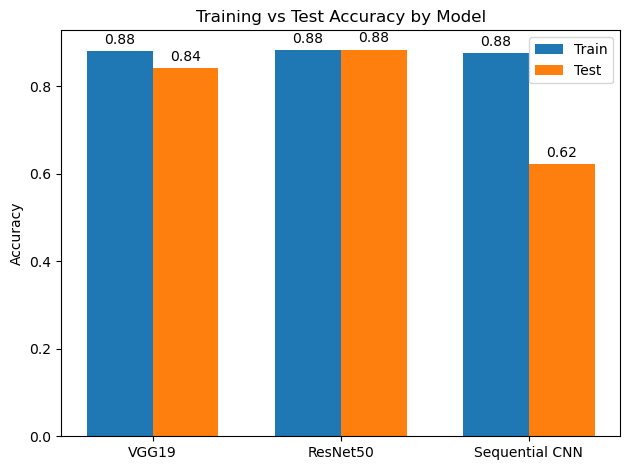

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['VGG19', 'ResNet50', 'Sequential CNN']

# Training Accuracies
train_accuracies = [vgg19_train_accuracy, resnet50_train_accuracy, sequential_cnn_train_accuracy]

# Test Accuracies
test_accuracies = [vgg19_accuracy, resnet50_accuracy, sequential_cnn_accuracy]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Test Accuracy by Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

# Function to attach a text label above each bar in *rects*, displaying its height.
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()


118/118 [==============================] - 17s 142ms/step


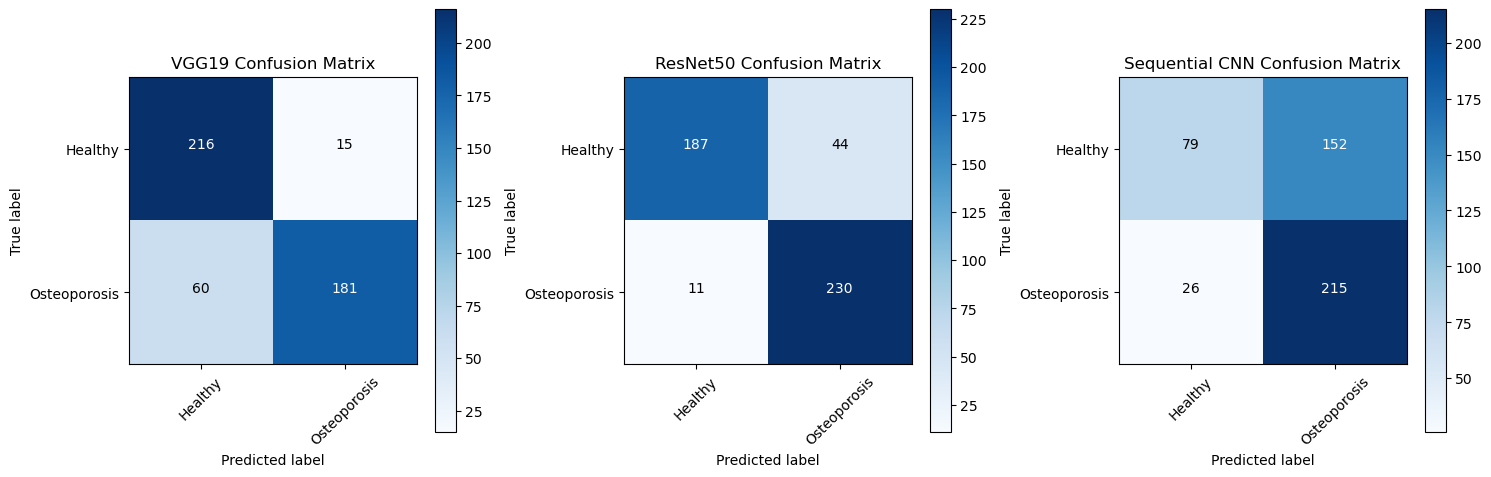

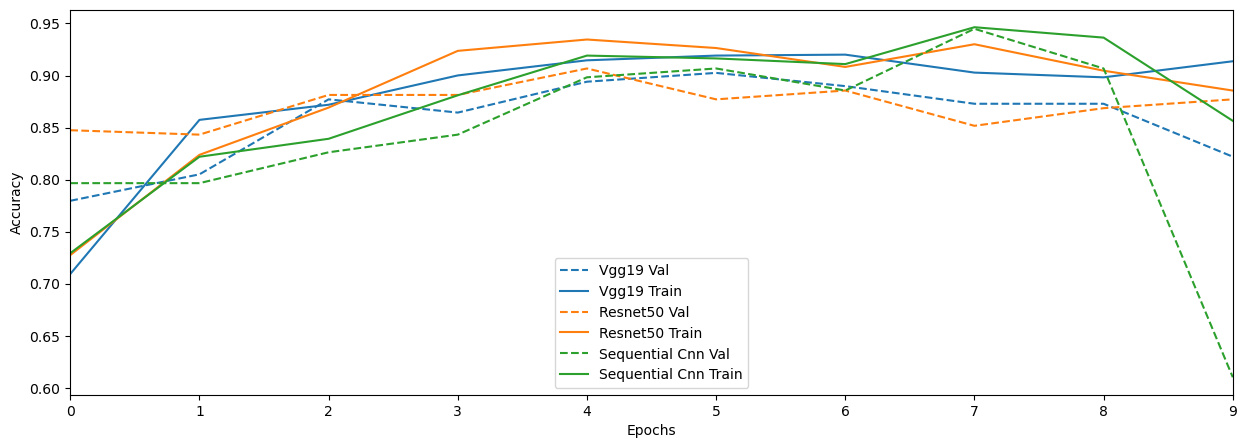

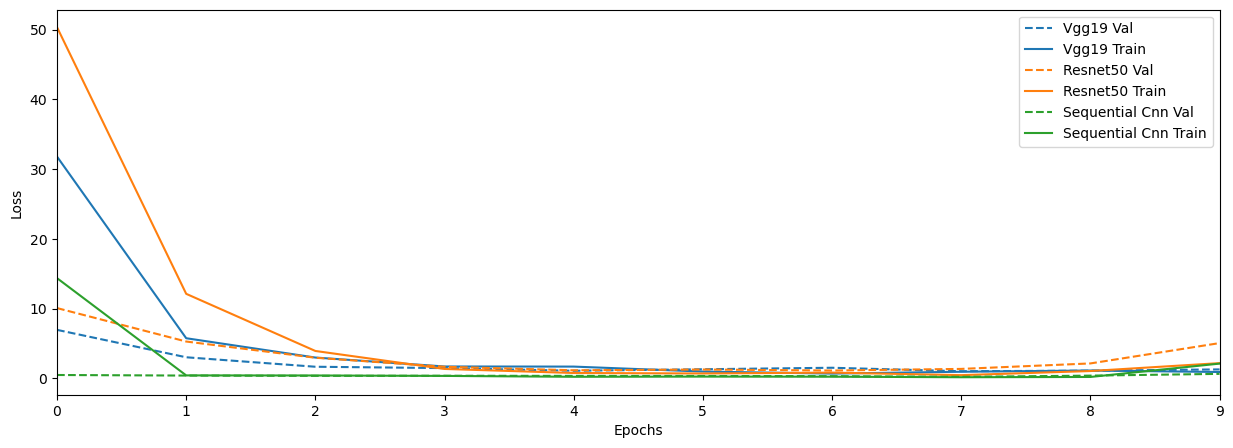

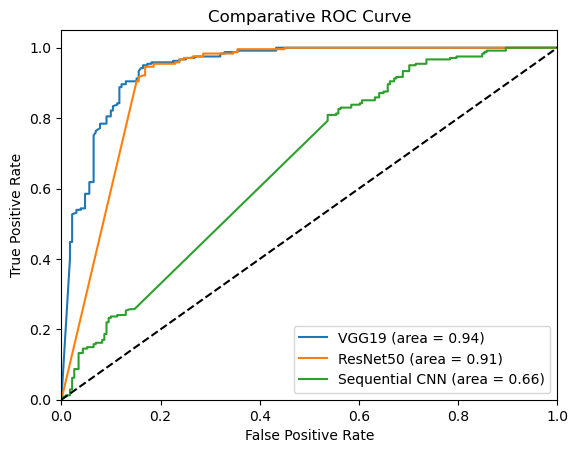

In [13]:
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Generate predictions for each model
vgg19_preds = vgg19_model.predict(test, verbose=1)
resnet50_preds = resnet50_model.predict(test, verbose=1)
sequential_cnn_preds = sequential_cnn_model.predict(test, verbose=1)

# Confusion matrices for each model
vgg19_cm = confusion_matrix(test.classes, np.argmax(vgg19_preds, axis=1))
resnet50_cm = confusion_matrix(test.classes, np.argmax(resnet50_preds, axis=1))
sequential_cnn_cm = confusion_matrix(test.classes, np.argmax(sequential_cnn_preds, axis=1))

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

# Plotting confusion matrices for all models
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plot_confusion_matrix(vgg19_cm, classes=test.class_indices.keys(), title='VGG19 Confusion Matrix')

plt.subplot(1, 3, 2)
plot_confusion_matrix(resnet50_cm, classes=test.class_indices.keys(), title='ResNet50 Confusion Matrix')

plt.subplot(1, 3, 3)
plot_confusion_matrix(sequential_cnn_cm, classes=test.class_indices.keys(), title='Sequential CNN Confusion Matrix')
plt.show()

# Function to plot training history
def plot_history(histories, key='accuracy'):
    plt.figure(figsize=(15, 5))

    for name, history in histories:
        val = plt.plot(history.epoch, history.history['val_'+key],
                       '--', label=name.title()+' Val')
        plt.plot(history.epoch, history.history[key], color=val[0].get_color(),
                 label=name.title()+' Train')

    plt.xlabel('Epochs')
    plt.ylabel(key.replace('_', ' ').title())
    plt.legend()

    plt.xlim([0, max(history.epoch)])

# Plotting training history for all models
plot_history([('VGG19', vgg19_history), ('ResNet50', resnet50_history), ('Sequential CNN', sequential_cnn_history)], key='accuracy')
plot_history([('VGG19', vgg19_history), ('ResNet50', resnet50_history), ('Sequential CNN', sequential_cnn_history)], key='loss')

# Calculate ROC curve and ROC area for each model
fpr, tpr, roc_auc = dict(), dict(), dict()
for i, model_preds in enumerate([vgg19_preds, resnet50_preds, sequential_cnn_preds]):
    fpr[i], tpr[i], _ = roc_curve(test.classes, model_preds[:, 1])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure()
plt.plot(fpr[0], tpr[0], label='VGG19 (area = %0.2f)' % roc_auc[0])
plt.plot(fpr[1], tpr[1], label='ResNet50 (area = %0.2f)' % roc_auc[1])
plt.plot(fpr[2], tpr[2], label='Sequential CNN (area = %0.2f)' % roc_auc[2])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparative ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [15]:
def fine_tune_model(model, start_layer, learning_rate=1e-5):
    # Make layers after 'start_layer' trainable
    for layer in model.layers[start_layer:]:
        layer.trainable = True
    
    # Recompile the model to apply the changes
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Fine-tuning VGG19
print("Fine-tuning VGG19")
# Assuming VGG19 is encapsulated and starts from index 1, adjust 'start_layer' as needed
fine_tune_model(vgg19_model, start_layer=19)  # Adjust based on the structure of your model
vgg19_history_ft1 = vgg19_model.fit(train, epochs=10, validation_data=val, verbose=1)

# Evaluate on test data
vgg19_loss_ft1, vgg19_accuracy_ft1 = vgg19_model.evaluate(test, verbose=1)
print(f"VGG19 Fine-tuned Accuracy: {vgg19_accuracy_ft1*100:.2f}%")

# Fine-tuning ResNet50
print("\nFine-tuning ResNet50")
# Assuming ResNet50 is encapsulated and starts from index 1, adjust 'start_layer' as needed
fine_tune_model(resnet50_model, start_layer=175)  # Adjust based on the structure of your model
resnet50_history_ft1 = resnet50_model.fit(train, epochs=10, validation_data=val, verbose=1)

# Evaluate on test data
resnet50_loss_ft1, resnet50_accuracy_ft1 = resnet50_model.evaluate(test, verbose=1)
print(f"ResNet50 Fine-tuned Accuracy: {resnet50_accuracy_ft1*100:.2f}%")


Fine-tuning VGG19
Epoch 1/10
276/276 [==============================] - 617s 2s/step - loss: 0.4150 - accuracy: 0.9201 - val_loss: 0.6082 - val_accuracy: 0.8898
Epoch 2/10
276/276 [==============================] - 693s 3s/step - loss: 0.2955 - accuracy: 0.9292 - val_loss: 0.5725 - val_accuracy: 0.8941
Epoch 3/10
276/276 [==============================] - 324s 1s/step - loss: 0.1611 - accuracy: 0.9473 - val_loss: 0.4366 - val_accuracy: 0.9025
Epoch 4/10
276/276 [==============================] - 304s 1s/step - loss: 0.0829 - accuracy: 0.9619 - val_loss: 0.4513 - val_accuracy: 0.9068
Epoch 5/10
276/276 [==============================] - 303s 1s/step - loss: 0.0989 - accuracy: 0.9682 - val_loss: 0.4660 - val_accuracy: 0.9025
Epoch 6/10
276/276 [==============================] - 312s 1s/step - loss: 0.0916 - accuracy: 0.9673 - val_loss: 0.3752 - val_accuracy: 0.9110
Epoch 7/10
276/276 [==============================] - 315s 1s/step - loss: 0.0821 - accuracy: 0.9619 - val_loss: 0.3453 - va

In [16]:
def fine_tune_model(model, start_layer, learning_rate=1e-6):
    # Make layers after 'start_layer' trainable
    for layer in model.layers[start_layer:]:
        layer.trainable = True
    
    # Recompile the model to apply the changes
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# Further fine-tuning VGG19
print("Further fine-tuning VGG19")
fine_tune_model(vgg19_model, start_layer=17)  # Unfreeze more layers cautiously
vgg19_history_ft2 = vgg19_model.fit(train, epochs=10, validation_data=val, verbose=1)

# Evaluate on test data
vgg19_loss_ft2, vgg19_accuracy_ft2 = vgg19_model.evaluate(test, verbose=1)
print(f"VGG19 Further Fine-tuned Accuracy: {vgg19_accuracy_ft2*100:.2f}%")

# Further fine-tuning ResNet50
print("\nFurther fine-tuning ResNet50")
fine_tune_model(resnet50_model, start_layer=170)  # Unfreeze more layers cautiously
resnet50_history_ft2 = resnet50_model.fit(train, epochs=10, validation_data=val, verbose=1)

# Evaluate on test data
resnet50_loss_ft2, resnet50_accuracy_ft2 = resnet50_model.evaluate(test, verbose=1)
print(f"ResNet50 Further Fine-tuned Accuracy: {resnet50_accuracy_ft2*100:.2f}%")


Further fine-tuning VGG19
Epoch 1/10
276/276 [==============================] - 307s 1s/step - loss: 0.0501 - accuracy: 0.9773 - val_loss: 0.4068 - val_accuracy: 0.9195
Epoch 2/10
276/276 [==============================] - 315s 1s/step - loss: 0.0591 - accuracy: 0.9682 - val_loss: 0.3554 - val_accuracy: 0.9195
Epoch 3/10
276/276 [==============================] - 310s 1s/step - loss: 0.0448 - accuracy: 0.9746 - val_loss: 0.3800 - val_accuracy: 0.9195
Epoch 4/10
276/276 [==============================] - 315s 1s/step - loss: 0.0469 - accuracy: 0.9718 - val_loss: 0.4224 - val_accuracy: 0.9280
Epoch 5/10
276/276 [==============================] - 315s 1s/step - loss: 0.0436 - accuracy: 0.9728 - val_loss: 0.4186 - val_accuracy: 0.9237
Epoch 6/10
276/276 [==============================] - 315s 1s/step - loss: 0.0439 - accuracy: 0.9728 - val_loss: 0.4201 - val_accuracy: 0.9237
Epoch 7/10
276/276 [==============================] - 316s 1s/step - loss: 0.0431 - accuracy: 0.9746 - val_loss: 0.4

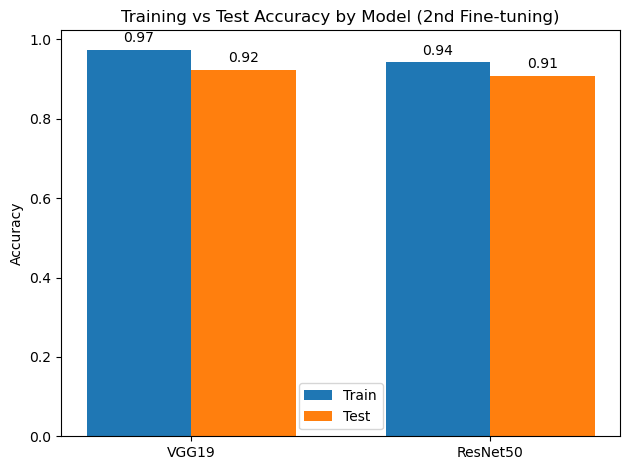

In [17]:
# Training and test accuracies after 2nd fine-tuning
vgg19_train_accuracy_ft2 = np.mean(vgg19_history_ft2.history['accuracy'])
vgg19_test_accuracy_ft2 = vgg19_accuracy_ft2

resnet50_train_accuracy_ft2 = np.mean(resnet50_history_ft2.history['accuracy'])
resnet50_test_accuracy_ft2 = resnet50_accuracy_ft2

models = ['VGG19', 'ResNet50']
train_accuracies_ft2 = [vgg19_train_accuracy_ft2, resnet50_train_accuracy_ft2]
test_accuracies_ft2 = [vgg19_test_accuracy_ft2, resnet50_test_accuracy_ft2]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, train_accuracies_ft2, width, label='Train')
rects2 = ax.bar(x + width/2, test_accuracies_ft2, width, label='Test')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Training vs Test Accuracy by Model (2nd Fine-tuning)')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()

plt.show()


118/118 [==============================] - 42s 317ms/step


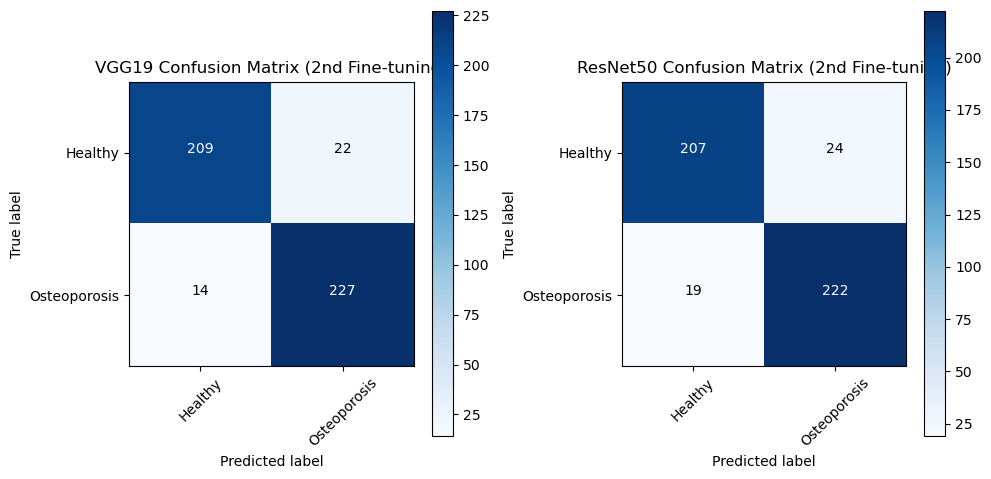

In [18]:
# Generate predictions after 2nd fine-tuning
vgg19_preds_ft2 = vgg19_model.predict(test, verbose=1)
resnet50_preds_ft2 = resnet50_model.predict(test, verbose=1)

# Confusion matrices after 2nd fine-tuning
vgg19_cm_ft2 = confusion_matrix(test.classes, np.argmax(vgg19_preds_ft2, axis=1))
resnet50_cm_ft2 = confusion_matrix(test.classes, np.argmax(resnet50_preds_ft2, axis=1))

plt.figure(figsize=(10, 5))

# VGG19
plt.subplot(1, 2, 1)
plot_confusion_matrix(vgg19_cm_ft2, classes=test.class_indices.keys(), title='VGG19 Confusion Matrix (2nd Fine-tuning)')

# ResNet50
plt.subplot(1, 2, 2)
plot_confusion_matrix(resnet50_cm_ft2, classes=test.class_indices.keys(), title='ResNet50 Confusion Matrix (2nd Fine-tuning)')

plt.tight_layout()
plt.show()


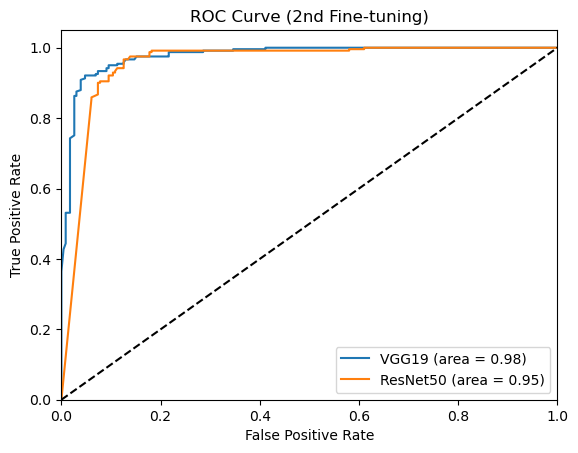

In [19]:
# Calculate ROC curve and ROC area for each model after 2nd fine-tuning
fpr_ft2, tpr_ft2, roc_auc_ft2 = dict(), dict(), dict()
for i, model_preds in enumerate([vgg19_preds_ft2, resnet50_preds_ft2]):
    fpr_ft2[i], tpr_ft2[i], _ = roc_curve(test.classes, model_preds[:, 1])
    roc_auc_ft2[i] = auc(fpr_ft2[i], tpr_ft2[i])

# Plotting the ROC curves
plt.figure()
plt.plot(fpr_ft2[0], tpr_ft2[0], label='VGG19 (area = %0.2f)' % roc_auc_ft2[0])
plt.plot(fpr_ft2[1], tpr_ft2[1], label='ResNet50 (area = %0.2f)' % roc_auc_ft2[1])
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (2nd Fine-tuning)')
plt.legend(loc="lower right")
plt.show()
